In [1]:
from astropy.io import fits
from reproject import reproject_interp
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import warnings
from astropy.wcs import FITSFixedWarning
warnings.simplefilter('ignore', FITSFixedWarning)

In [2]:
path_image_1 = "/home/wesley/Desktop/JWST_REU/Jorgensen_2024/"
path_image_2 = "/home/wesley/Desktop/JWST_REU/HEFE_2025/"

In [3]:
hdu_1 = fits.open((path_image_1 + 'nan_rm_Jorgensen_2024_f212n.fits'))[1]
hdu_2= fits.open((path_image_2 + 'hefe_2025_F212N.fits'))[1]

In [4]:
hdul_1 = fits.open((path_image_1 + 'nan_rm_Jorgensen_2024_f212n.fits'))
hdul_2= fits.open((path_image_2 + 'hefe_2025_F212N.fits'))

**132 days**
2024-10-17 to
2025-02-26 

In [6]:
array_new = reproject_interp(hdu_2, hdu_1.header)

In [7]:
primary = fits.PrimaryHDU()
primary.header = hdul_2[0].header

In [8]:
image = fits.ImageHDU(data=array_new[0])
image.header["EXTNAME"] = "SCI"

wcs = WCS(hdul_1[1].header)
image.header.update(wcs.to_header())


hdul = fits.HDUList([primary, image])
hdul.writeto(path_image_2 + "repro_hefe_2025_F212N.fits", overwrite=True)

In [9]:
hdul_3 = fits.open((path_image_2 + 'repro_hefe_2025_F212N.fits'))

In [10]:
hdul_3[1].data

array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.41884494, 0.4901807 , 0.58123034, ...,        nan,        nan,
               nan],
       [0.41069388, 0.31354341, 0.50355053, ...,        nan,        nan,
               nan],
       [0.49467754, 0.33322203, 0.41781864, ...,        nan,        nan,
               nan]], shape=(10083, 11499), dtype='>f8')

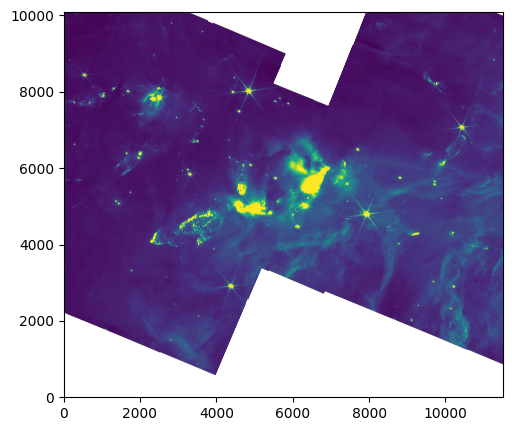

In [11]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.imshow(hdul_3[1].data, vmin=0, vmax=30, origin="lower")
print()